In [13]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [14]:
x = np.random.randint(-40,40,size=(1000,2))
y = np.reshape([i[0]*3+i[1]*4 for i in x],shape=(-1,1))
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [15]:
model = Sequential([
    
    Dense(15, activation='sigmoid', input_shape=(2,)),
    Dense(1, activation='linear'),
])

# Compilação
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

# Resumo
model.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 15)             │            45 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61 (244.00 B)

 Trainable params: 61 (244.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Treinamento
model.fit(
    x_train, y_train,
    epochs=1000,
    validation_split=0.2,
    verbose=1
)

Epoch 1/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 14145.9873 - mae: 97.4350 - val_loss: 12222.9990 - val_mae: 90.4884
Epoch 2/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14115.2637 - mae: 97.3250 - val_loss: 12196.0342 - val_mae: 90.3799
Epoch 3/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14084.3799 - mae: 97.2132 - val_loss: 12169.8330 - val_mae: 90.2742
Epoch 4/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14052.8643 - mae: 97.1005 - val_loss: 12144.3203 - val_mae: 90.1713
Epoch 5/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14021.9795 - mae: 96.9880 - val_loss: 12116.6172 - val_mae: 90.0607
Epoch 6/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13988.7705 - mae: 96.8703 - val_loss: 12088.1553 - val_mae: 89.9471
Epoch 7/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13954.4717 - mae: 96.7478 - val_loss: 12057.4512 - val_mae: 89.8264
Epoch 8/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13918.5723 - mae: 96.6195 - val_loss: 12024.

1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/stepWARNING:tensorflow:5 out of the last 15 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000022B0EF17880> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


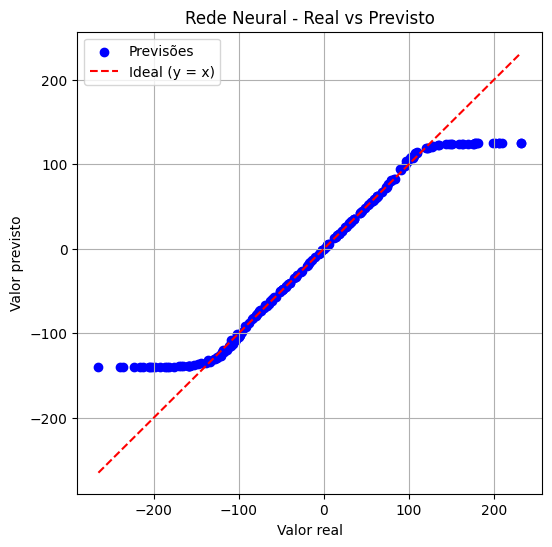

In [17]:
y_pred = model.predict(x_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue', label='Previsões')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    label='Ideal (y = x)'
)

plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title("Rede Neural - Real vs Previsto")
plt.legend()
plt.grid()

plt.show()

In [18]:

model.predict(np.array([[1, 0.5]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


array([[5.2343]], dtype=float32)

In [19]:
weights = model.weights

FRAC = 16
SCALE = 1 << FRAC

INT32_MAX = 2**31 - 1
INT32_MIN = -(2**31)


#Transforma float para Q16
def float_to_q16(val):
    if np.isnan(val):
        return 0
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN

    fixed = int(np.round(val * SCALE))
    return max(INT32_MIN, min(INT32_MAX, fixed))

# Endereço: [layer(3 bits)][is_bias(1 bit)][neuron(4 bits)][input_idx(4 bits)]
def build_addr(layer, is_bias, neuron, idx):
    return (layer << 9) | (is_bias << 8) | (neuron << 4) | idx

# Export mem
mem = {}

layer_idx = 0
i = 0

while i < len(weights):

    kernel = weights[i].numpy().T
    bias   = weights[i+1].numpy()

    n_neurons, n_inputs = kernel.shape

    #Peso
    for n in range(n_neurons):
        for inp in range(n_inputs):

            if n >= 16 or inp >= 16:
                raise ValueError("Excedeu limite de 4 bits")

            addr = build_addr(layer_idx, 0, n, inp)
            mem[addr] = float_to_q16(kernel[n][inp])

    #Viés
    for n in range(n_neurons):

        if n >= 16:
            raise ValueError("Excedeu limite de 4 bits")

        addr = build_addr(layer_idx, 1, n, 0)
        mem[addr] = float_to_q16(bias[n])

    layer_idx += 1
    i += 2



max_addr = max(mem.keys())

with open("weights.mem", "w") as f:
    for addr in range(max_addr + 1):
        val = mem.get(addr, 0)

        # two's complement se negativo
        if val < 0:
            val = (1 << 32) + val

        f.write(f"{val:08x}\n")

print("Arquivo salvo: weights.mem")

Arquivo salvo: weights.mem
